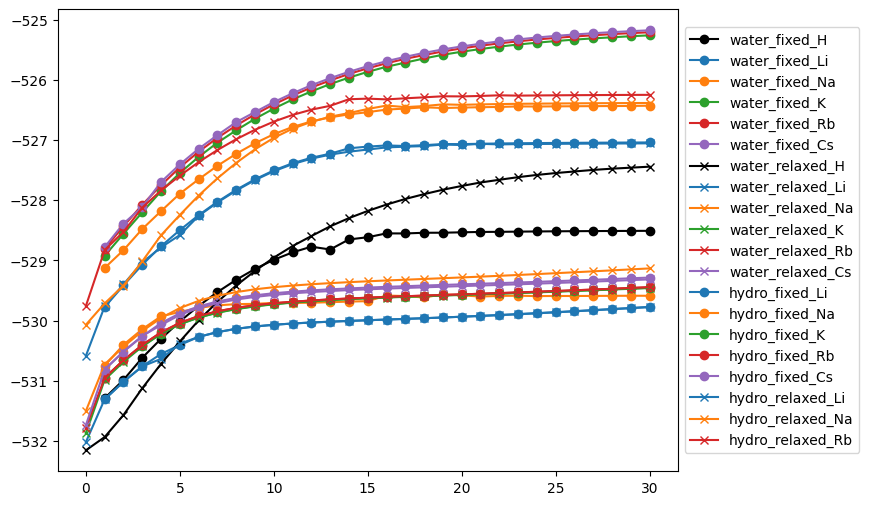

In [ ]:
import os
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

root = '/Users/hailey/Desktop/1_cation/3_PES'

df = pd.DataFrame(index=range(31))
for solv in ['1_cation_water', '2_cation_hydroxide']:
    solv_name = 'water' if solv == '1_cation_water' else 'hydro'
    for dir in ['pes', 'relaxed-pes']:
        dir_name = 'fixed' if dir == 'pes' else 'relaxed'
        for subdir in ['0_H', '1_Li', '2_Na', '3_K', '4_Rb', '5_Cs']:
            subdir_name = subdir.split('_')[1]
            for i in range(31):
                filename = os.path.join(root, solv, dir, subdir, f'{i:02d}_', 'final_with_calculator.json')
                if os.path.isfile(filename):
                    energy = read(filename).get_potential_energy()
                    df.loc[i, f'{solv_name}_{dir_name}_{subdir_name}'] = energy

df = df - df.loc['index=']
plt.figure(figsize=(8, 6))
for col in df.columns:
    if 'H' in col:
        color = 'black'
    elif 'Li' in col:
        color = 'tab:blue'
    elif 'Na' in col:
        color = 'tab:orange'
    elif 'K' in col:
        color = 'tab:green'
    elif 'Rb' in col:
        color = 'tab:red'
    elif 'Cs' in col:
        color = 'tab:purple'

    if 'fixed' in col:
        marker = 'o'
    elif 'relaxed' in col:
        marker = 'x'
    plt.plot(df.index, df[col], marker=marker, label=col, color=color)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()